# Lung Cancer Treatment Outcome Prediction

## Hierarchical CatBoost Pipeline

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


# 1. Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

from imblearn.over_sampling import SMOTENC
import shap


# 2. Load Dataset

In [9]:
df = pd.read_excel("/content/drive/MyDrive/xp.xlsx")
print("Dataset shape:", df.shape)


Dataset shape: (164, 14)


# 3. Feature Engineering (TNM Score)

In [10]:
df["T_score"] = df["diagnoses.ajcc_pathologic_t"].str.extract(r'(\d)').astype(float).fillna(0)
df["N_score"] = df["diagnoses.ajcc_pathologic_n"].str.extract(r'(\d)').astype(float).fillna(0)
df["M_score"] = df["diagnoses.ajcc_pathologic_m"].str.extract(r'(\d)').astype(float).fillna(0)

df["TNM_score"] = df["T_score"] + df["N_score"] + df["M_score"]


# 4. Response Group (Hierarchical Classification)

In [11]:
df["response_group"] = df["treatments.treatment_outcome"].map({
    "Complete Response":"Responder",
    "Partial Response":"Responder",
    "Stable Disease":"NonResponder",
    "Progressive Disease":"NonResponder"
})


 # 5. Prepare Features


In [13]:
target = "treatments.treatment_outcome"

X = df.drop(columns=[target])
y = df[target]

X = X.drop(columns=["response_group"])

cat_cols = X.select_dtypes(include="object").columns.tolist()

for c in cat_cols:
    X[c] = X[c].astype("category")

X_encoded = X.copy()

for c in cat_cols:
    X_encoded[c] = X_encoded[c].cat.codes

X_encoded = X_encoded.fillna(0)


 # 6. Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



# 7. SMOTENC Oversampling

In [15]:
cat_idx = [X_encoded.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(
    categorical_features=cat_idx,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


# 8. Model 1 – Responder vs NonResponder

In [16]:
group_train = y_train_res.map({
    "Complete Response":"Responder",
    "Partial Response":"Responder",
    "Stable Disease":"NonResponder",
    "Progressive Disease":"NonResponder"
})

model_group = CatBoostClassifier(
    iterations=1200,
    depth=6,
    learning_rate=0.03,
    verbose=0
)

model_group.fit(X_train_res, group_train)

CatBoostClassifier(depth=6, iterations=1200, learning_rate=0.03, verbose=0)

# 9. Model 2 – Complete vs Partial


In [17]:
mask_resp = y_train_res.isin(["Complete Response","Partial Response"])

model_resp = CatBoostClassifier(
    iterations=1000,
    depth=5,
    learning_rate=0.03,
    verbose=0
)

model_resp.fit(
    X_train_res[mask_resp],
    y_train_res[mask_resp]
)


CatBoostClassifier(depth=5, iterations=1000, learning_rate=0.03, verbose=0)

# 10. Model 3 - Stable vs Progressive

In [18]:
mask_non = y_train_res.isin(["Stable Disease","Progressive Disease"])

model_non = CatBoostClassifier(
    iterations=1000,
    depth=5,
    learning_rate=0.03,
    verbose=0
)

model_non.fit(
    X_train_res[mask_non],
    y_train_res[mask_non]
)


CatBoostClassifier(depth=5, iterations=1000, learning_rate=0.03, verbose=0)

# 11. Hierarchical Prediction

In [19]:

pred_group = model_group.predict(X_test)

final_pred = []

for i,g in enumerate(pred_group):

    if g == "Responder":
        pred = model_resp.predict(X_test.iloc[[i]])[0]

    else:
        pred = model_non.predict(X_test.iloc[[i]])[0]

    final_pred.append(pred)

# 12. Evaluation

In [20]:

print("Accuracy:", accuracy_score(y_test, final_pred))

print("\nClassification Report\n")
print(classification_report(y_test, final_pred))


Accuracy: 0.8484848484848485

Classification Report

                     precision    recall  f1-score   support

  Complete Response       0.94      0.83      0.88        18
   Partial Response       0.50      0.67      0.57         3
Progressive Disease       0.89      1.00      0.94         8
     Stable Disease       0.75      0.75      0.75         4

           accuracy                           0.85        33
          macro avg       0.77      0.81      0.79        33
       weighted avg       0.86      0.85      0.85        33



# 13. Confusion Matrix

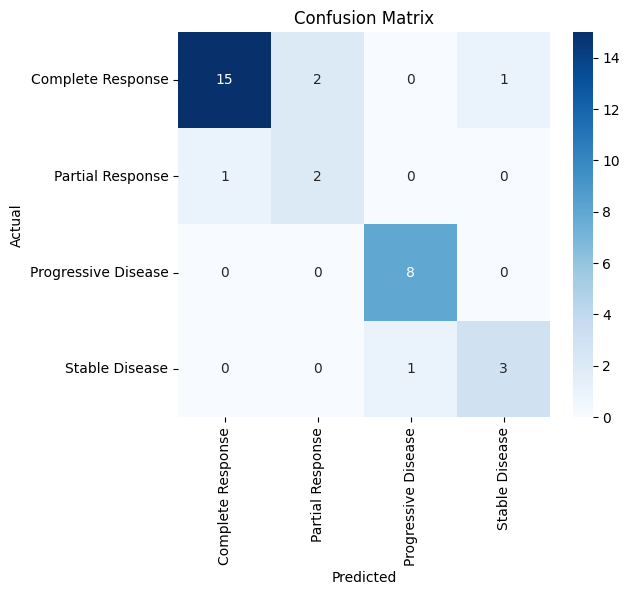

In [24]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# 14. ROC-AUC

In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = [
    "Complete Response",
    "Partial Response",
    "Stable Disease",
    "Progressive Disease"
]

y_test_bin = label_binarize(y_test, classes=classes)
y_pred_bin = label_binarize(final_pred, classes=classes)

auc = roc_auc_score(y_test_bin, y_pred_bin, multi_class="ovr")

print("Correct ROC-AUC:", auc)


Correct ROC-AUC: 0.8802729885057471


# 15. SHAP

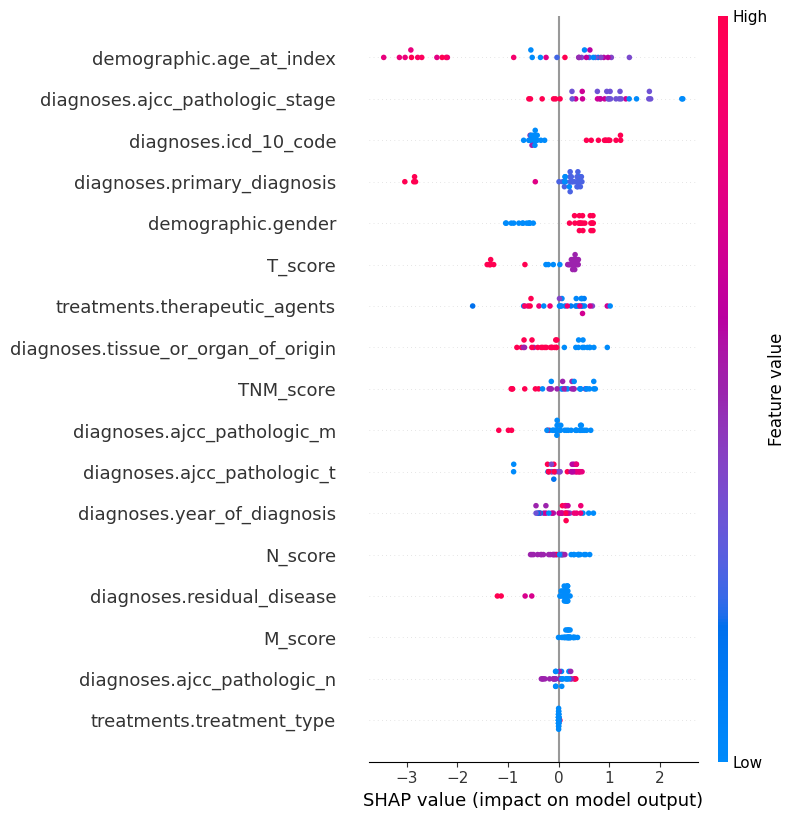

In [26]:
explainer = shap.TreeExplainer(model_group)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
